In [86]:
# Imports
from matplotlib.animation import FuncAnimation
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.signal import resample
import matplotlib.pyplot as plt
from animations import animate
import matplotlib.cm as cm
import seaborn as sns
import pandas as pd
import numpy as np
import joblib
import json

In [87]:
pca = joblib.load('./data/pca_model.joblib')
scaler = joblib.load("./data/scaler_model.joblib")

In [88]:
pivot_df = pd.read_parquet("../data/pivot.parquet").reset_index()
normalized_raw = pd.read_parquet("./data/normalized_raw.parquet")
scores_df = pd.read_parquet("./data/pca_results.parquet")

In [89]:
print("pivot_df")
display(pivot_df.head(3))
print("\n\nFrame Normalized pivot_df")
display(normalized_raw.head(3))
print("\n\nPC Scores")
display(scores_df.head(3))

pivot_df


,userID,sessionID,pitchNum,height,weight,frame,pitchType,pitchSpeed,p_throws,x_C7,...,z_RPSI,z_RSHO,z_RTHI,z_RTIB,z_RTOE,z_RUPA,z_RWRA,z_RWRB,z_STRN,z_T10
0,000002,003034,002,73,207,0,FF,80.9,R,0.003564,...,1.093330,1.518690,0.719840,0.413118,0.110978,1.335941,1.210881,1.153992,1.300240,1.270855
1,000002,003034,002,73,207,1,FF,80.9,R,0.004078,...,1.093523,1.518930,0.719549,0.412286,0.110229,1.336155,1.210987,1.154228,1.300375,1.271011
2,000002,003034,002,73,207,2,FF,80.9,R,0.004623,...,1.093809,1.519287,0.719221,0.411515,0.109155,1.336329,1.211178,1.154594,1.300462,1.271312




Frame Normalized pivot_df


,frame_norm,x_C7,x_CLAV,x_LANK,x_LASI,x_LBHD,x_LELB,x_LFHD,x_LFIN,x_LFRM,...,z_RWRB,z_STRN,z_T10,userID,sessionID,pitchNum,height,weight,pitchType,pitchSpeed
0,0.0,0.003564,0.057339,0.183473,0.217727,-0.001984,0.361450,0.120232,0.257619,0.323177,...,1.153992,1.300240,1.270855,000002,003034,002,73,207,FF,80.9
1,1.0,0.007236,0.058021,0.183709,0.218794,0.001263,0.364117,0.123117,0.255129,0.323549,...,1.155824,1.301268,1.272222,000002,003034,002,73,207,FF,80.9
2,2.0,0.010686,0.058724,0.183614,0.220303,0.004052,0.366343,0.125543,0.252164,0.323490,...,1.158136,1.301872,1.272980,000002,003034,002,73,207,FF,80.9




PC Scores


,userID,sessionID,pitchNum,height,weight,frame,pitchType,pitchSpeed,p_throws,PC1,PC2,PC3
0,000002,003034,002,73,207,0,FF,80.9,R,-5.801177,3.128596,1.112119
1,000002,003034,002,73,207,1,FF,80.9,R,-5.806602,3.125332,1.142782
2,000002,003034,002,73,207,2,FF,80.9,R,-5.812494,3.122450,1.172256


In [97]:
def get_eigenmotion(motion_df, pca, scaler, pc_index, stdev, frame_name = 'frame'):
    marker_cols = [c for c in motion_df.columns if c.startswith(('x_','y_','z_'))]
    
    # Average marker location by frame
    X_avg = motion_df.groupby(frame_name, as_index = False)[marker_cols].mean()

    # Eigenvector P_i
    P = pca.components_[pc_index]
    
    # Eigenvalue lambda_i
    lambda_ = pca.explained_variance_[pc_index]

    # Weight for eigenvector
    W_k = stdev * np.sqrt(lambda_)
    
    # Contribution of eigenvector to motion
    contribution_vector = W_k * P

    # Scale average motion
    X_avg_scaled = scaler.transform(X_avg[marker_cols].values)
    
    # Add the eigenvector contribution to the average motion
    X_eigenmotion_scaled = X_avg_scaled + contribution_vector
    
    # Transform the final motion back to the original data space
    X_eigenmotion = scaler.inverse_transform(X_eigenmotion_scaled)

    # Format the output dataframe
    df_wide = pd.DataFrame(X_eigenmotion, columns=marker_cols)
    
    # Retrieve frames from X_avg
    df_wide[frame_name] = X_avg[frame_name].values
    
    # Melt x, y, z
    x_cols = [c for c in df_wide.columns if c.startswith('x_')]
    y_cols = [c for c in df_wide.columns if c.startswith('y_')]
    z_cols = [c for c in df_wide.columns if c.startswith('z_')]
    
    df_x = df_wide.melt(id_vars=frame_name, value_vars=x_cols, var_name='coord', value_name='x')
    df_x['markerID'] = df_x['coord'].str[2:]
    df_x = df_x.drop(columns='coord')

    df_y = df_wide.melt(id_vars=frame_name, value_vars=y_cols, var_name='coord', value_name='y')
    df_y['markerID'] = df_y['coord'].str[2:]
    df_y = df_y.drop(columns='coord')

    df_z = df_wide.melt(id_vars=frame_name, value_vars=z_cols, var_name='coord', value_name='z')
    df_z['markerID'] = df_z['coord'].str[2:]
    df_z = df_z.drop(columns='coord')
    
    long_df = df_x.merge(df_y, on=[frame_name,'markerID']).merge(df_z, on=[frame_name,'markerID'])
    long_df['frame'] = long_df[frame_name]
    return long_df

Saving animation... please wait.
On frame 0 of animation
On frame 0 of animation
On frame 100 of animation
On frame 200 of animation
On frame 300 of animation
On frame 400 of animation
On frame 500 of animation
On frame 600 of animation
On frame 700 of animation
On frame 800 of animation
On frame 900 of animation
On frame 1000 of animation
On frame 1100 of animation
Animation saved as pc1_stdev3_pos.mp4


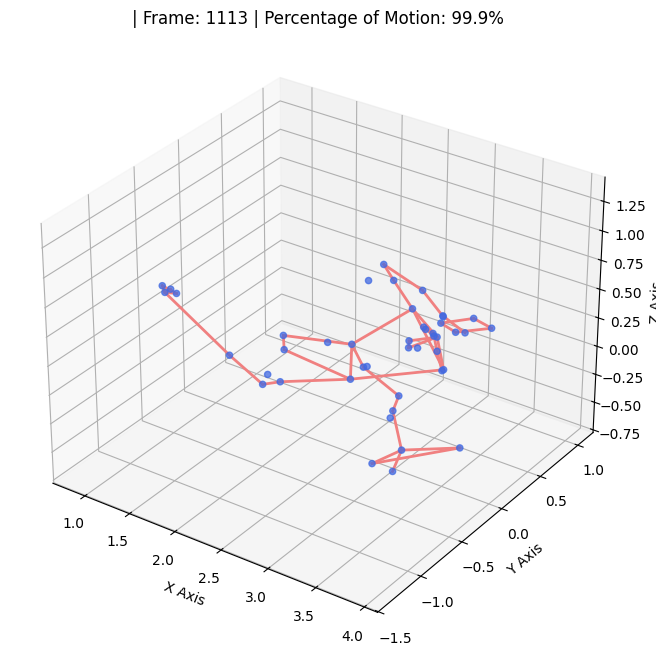

In [91]:
pc1_stdev3_pos = get_eigenmotion(pivot_df, pca, scaler, 0, 3)
pc1_stdev3_pos.head(2)
animate(pc1_stdev3_pos, 'theoretical', 'pc1_stdev3_pos')

In [100]:
scores_df = pd.read_parquet("./data/pca_results.parquet")
scores_df.head()

,userID,sessionID,pitchNum,height,weight,frame,pitchType,pitchSpeed,p_throws,PC1,PC2,PC3
0,000002,003034,002,73,207,0,FF,80.9,R,-5.801177,3.128596,1.112119
1,000002,003034,002,73,207,1,FF,80.9,R,-5.806602,3.125332,1.142782
2,000002,003034,002,73,207,2,FF,80.9,R,-5.812494,3.122450,1.172256
3,000002,003034,002,73,207,3,FF,80.9,R,-5.816327,3.120327,1.191390
4,000002,003034,002,73,207,4,FF,80.9,R,-5.821762,3.116908,1.221027


Saving animation... please wait.
On frame 0 of animation
On frame 0 of animation
On frame 100 of animation
Animation saved as norm_pc1_stdev3_pos.mp4


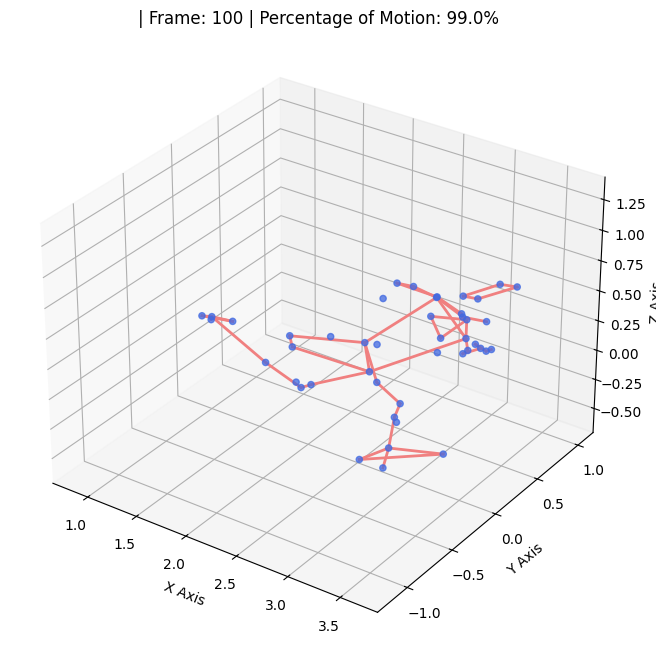

In [98]:
norm_pc1_stdev3_pos = get_eigenmotion(normalized_raw, pca, scaler, 0, 3, 'frame_norm')
norm_pc1_stdev3_pos.head(2)
animate(norm_pc1_stdev3_pos, 'theoretical', 'norm_pc1_stdev3_pos')

In [203]:
import pandas as pd
import numpy as np

# Assuming 'pca' is your fitted PCA object and 'marker_cols' lists your features
loadings_df = pd.DataFrame(
    pca.components_,
    columns=marker_cols,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

loadings_df.reset_index(inplace = True)
loadings_df.rename(columns = {'index': 'PC'}, inplace= True)
melted_loadings = loadings_df.melt(id_vars = 'PC', var_name = 'coord_marker', value_name = 'value')
melted_loadings['abs_value'] = np.abs(melted_loadings['value'])

melted_loadings['marker'] = melted_loadings['coord_marker'].str.split('_').str.get(1)

marker_contrib = (
    melted_loadings
    .groupby(['PC', 'marker'])
    .agg(total_contrib=('value', lambda x: np.sum(np.abs(x))))
    .reset_index()
)

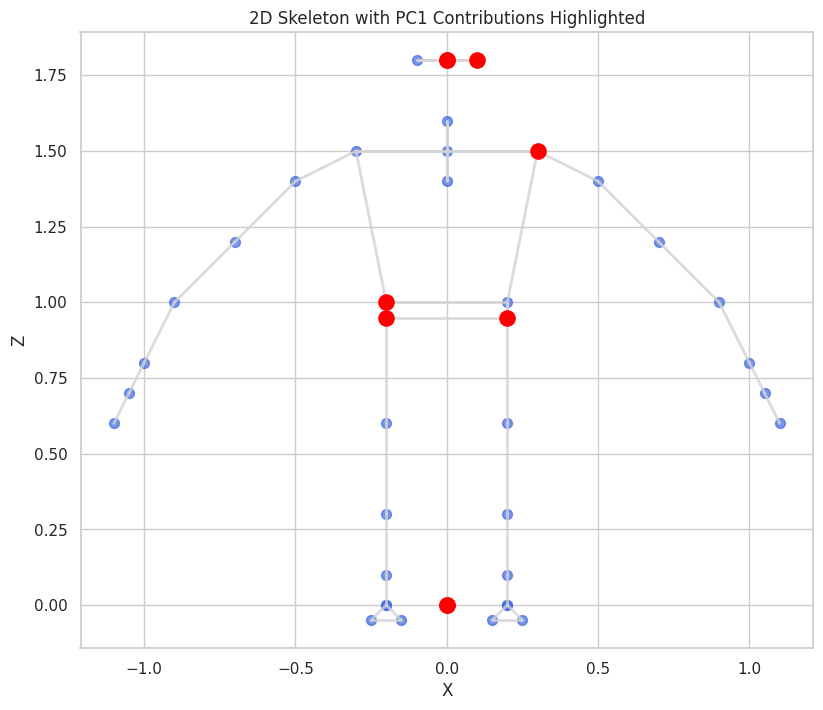

In [ ]:
# Marker list
markers = ['C7', 'CLAV', 'LANK', 'LASI', 'LBHD', 'LELB', 'LFHD', 'LFIN',
       'LFRM', 'LHEE', 'LKNE', 'LMANK', 'LMELB', 'LMKNE', 'LPSI', 'LSHO',
       'LTHI', 'LTIB', 'LTOE', 'LUPA', 'LWRA', 'LWRB', 'RANK', 'RASI',
       'RBAK', 'RBHD', 'RELB', 'RFHD', 'RFIN', 'RFRM', 'RHEE', 'RKNE',
       'RMANK', 'RMELB', 'RMKNE', 'RPSI', 'RSHO', 'RTHI', 'RTIB', 'RTOE',
       'RUPA', 'RWRA', 'RWRB', 'STRN', 'T10']

num_markers = len(markers)
marker_to_idx = {m:i for i,m in enumerate(markers)}


points = np.zeros((3, num_markers))

# Head
points[:, marker_to_idx['LBHD']] = [0, 0, 1.8]
points[:, marker_to_idx['LFHD']] = [0.1, 0, 1.8]
points[:, marker_to_idx['RBHD']] = [-0.1, 0, 1.8]
points[:, marker_to_idx['RFHD']] = [0, 0.01, 1.8]
points[:, marker_to_idx['C7']]   = [0, 0, 1.6]
points[:, marker_to_idx['STRN']] = [0, 0, 1.4]
points[:, marker_to_idx['CLAV']] = [0, 0, 1.5]

# Shoulders
points[:, marker_to_idx['LSHO']] = [0.3, 0, 1.5]
points[:, marker_to_idx['RSHO']] = [-0.3, 0, 1.5]

# Arms
points[:, marker_to_idx['LUPA']] = [0.5, 0, 1.4]
points[:, marker_to_idx['LELB']] = [0.7, 0, 1.2]
points[:, marker_to_idx['LFRM']] = [0.9, 0, 1.0]
points[:, marker_to_idx['LWRA']] = [1.0, 0, 0.8]
points[:, marker_to_idx['LWRB']] = [1.05, 0, 0.7]
points[:, marker_to_idx['LFIN']] = [1.1, 0, 0.6]

points[:, marker_to_idx['RUPA']] = [-0.5, 0, 1.4]
points[:, marker_to_idx['RELB']] = [-0.7, 0, 1.2]
points[:, marker_to_idx['RFRM']] = [-0.9, 0, 1.0]
points[:, marker_to_idx['RWRA']] = [-1.0, 0, 0.8]
points[:, marker_to_idx['RWRB']] = [-1.05, 0, 0.7]
points[:, marker_to_idx['RFIN']] = [-1.1, 0, 0.6]

# Torso / hips
points[:, marker_to_idx['LASI']] = [0.2, 0, 1.0]
points[:, marker_to_idx['RASI']] = [-0.2, 0, 1.0]
points[:, marker_to_idx['LPSI']] = [0.2, -0.01, 0.95]
points[:, marker_to_idx['RPSI']] = [-0.2, -0.01, 0.95]

# Legs
points[:, marker_to_idx['LTHI']] = [0.2, 0, 0.6]
points[:, marker_to_idx['LKNE']] = [0.2, 0, 0.3]
points[:, marker_to_idx['LTIB']] = [0.2, 0, 0.1]
points[:, marker_to_idx['LANK']] = [0.2, 0, 0]
points[:, marker_to_idx['LHEE']] = [0.15, 0, -0.05]
points[:, marker_to_idx['LTOE']] = [0.25, 0, -0.05]
points[:, marker_to_idx['LMANK']] = [0.2, -0.01, 0]

points[:, marker_to_idx['RTHI']] = [-0.2, 0, 0.6]
points[:, marker_to_idx['RKNE']] = [-0.2, 0, 0.3]
points[:, marker_to_idx['RTIB']] = [-0.2, 0, 0.1]
points[:, marker_to_idx['RANK']] = [-0.2, 0, 0]
points[:, marker_to_idx['RHEE']] = [-0.15, 0, -0.05]
points[:, marker_to_idx['RTOE']] = [-0.25, 0, -0.05]
points[:, marker_to_idx['RMANK']] = [-0.2, -0.01, 0]

# ----------------------------------------------------------
# CONTRIBUTION LOGIC (ADD THIS)
# ----------------------------------------------------------
# Example:
# pc1_contrib = pd.Series({'LSHO':0.25, 'LELB':0.19, 'RSHO':0.18, ...})

# For demonstration, simulate contribs:
import pandas as pd
pc1_contrib = (
    marker_contrib
    .query("PC == 'PC1'")
    .set_index('marker')['total_contrib']
    .reindex(markers)        # keep same order as points[] array
    .fillna(0)               # missing markers → 0 contribution
)

# Normalize to determine "important" markers
cutoff = pc1_contrib.quantile(0.80)
important = set(pc1_contrib[pc1_contrib >= cutoff].index)


# ----------------------------------------------------------
# Connections
# ----------------------------------------------------------
def get_idx(label):
    return marker_to_idx.get(label)

connections_labels = [
    (get_idx('LBHD'), get_idx('LFHD')),
    (get_idx('RBHD'), get_idx('RFHD')),
    (get_idx('LFHD'), get_idx('RFHD')),
    (get_idx('LBHD'), get_idx('RBHD')),
    (get_idx('C7'), get_idx('STRN')),
    (get_idx('C7'), get_idx('CLAV')),
    (get_idx('STRN'), get_idx('CLAV')),
    (get_idx('CLAV'), get_idx('LSHO')),
    (get_idx('CLAV'), get_idx('RSHO')),
    (get_idx('LSHO'), get_idx('RSHO')),
    (get_idx('LSHO'), get_idx('LASI')),
    (get_idx('RSHO'), get_idx('RASI')),
    (get_idx('LASI'), get_idx('RASI')),
    (get_idx('LPSI'), get_idx('RPSI')),
    (get_idx('LASI'), get_idx('LPSI')),
    (get_idx('RASI'), get_idx('RPSI')),
    (get_idx('LSHO'), get_idx('LUPA')),
    (get_idx('LUPA'), get_idx('LELB')),
    (get_idx('LELB'), get_idx('LFRM')),
    (get_idx('LFRM'), get_idx('LWRA')),
    (get_idx('LWRA'), get_idx('LWRB')),
    (get_idx('LWRB'), get_idx('LFIN')),
    (get_idx('RSHO'), get_idx('RUPA')),
    (get_idx('RUPA'), get_idx('RELB')),
    (get_idx('RELB'), get_idx('RFRM')),
    (get_idx('RFRM'), get_idx('RWRA')),
    (get_idx('RWRA'), get_idx('RWRB')),
    (get_idx('RWRB'), get_idx('RFIN')),
    (get_idx('LASI'), get_idx('LTHI')),
    (get_idx('LTHI'), get_idx('LKNE')),
    (get_idx('LKNE'), get_idx('LTIB')),
    (get_idx('LTIB'), get_idx('LANK')),
    (get_idx('LANK'), get_idx('LHEE')),
    (get_idx('LANK'), get_idx('LTOE')),
    (get_idx('LHEE'), get_idx('LTOE')),
    (get_idx('LANK'), get_idx('LMANK')),
    (get_idx('RASI'), get_idx('RTHI')),
    (get_idx('RTHI'), get_idx('RKNE')),
    (get_idx('RKNE'), get_idx('RTIB')),
    (get_idx('RTIB'), get_idx('RANK')),
    (get_idx('RANK'), get_idx('RHEE')),
    (get_idx('RANK'), get_idx('RTOE')),
    (get_idx('RHEE'), get_idx('RTOE')),
    (get_idx('RANK'), get_idx('RMANK'))
]

# ----------------------------------------------------------
# PLOT
# ----------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

# Plot markers with PC1 coloring
for m in markers:
    idx = marker_to_idx[m]
    x = points[0, idx]
    z = points[2, idx]

    if m in important:
        ax.scatter(x, z, color='red', s=120, zorder=3)
    else:
        ax.scatter(x, z, color='royalblue', s=50, alpha=0.7)

# Skeleton lines
for p1, p2 in connections_labels:
    ax.plot(
        [points[0, p1], points[0, p2]],
        [points[2, p1], points[2, p2]],
        color='lightgray',
        lw=2,
        alpha=0.8
    )

ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_title('2D Skeleton with PC1 Contributions Highlighted')
ax.set_aspect('equal')
plt.show()


In [190]:
df

,x,y,z
marker,,,
LBHD,0.00,0.00,1.80
LFHD,0.10,0.00,1.80
RBHD,-0.10,0.00,1.80
RFHD,0.00,0.01,1.80
C7,0.00,0.00,1.60
STRN,0.00,0.00,1.40
CLAV,0.00,0.00,1.50
LSHO,0.30,0.00,1.50
RSHO,-0.30,0.00,1.50
